# Optimización Hiperparamétrica con GridSearchCV y GPU
**Alumno:** Aaron Fernández Pinto López  
**Dataset:** Fashion-MNIST  
**Modelo:** Red neuronal densa (SciKeras + GridSearchCV)  
**Entorno:** Google Colab con GPU T4 (vía Antigravity)

## 1. Verificación de GPU

In [ ]:
!nvidia-smi

Sat Feb 28 07:15:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Instalación de SciKeras (wrapper sklearn-compatible para Keras)
# Se fijan versiones compatibles para evitar conflictos con sklearn 1.6+
%pip install "scikeras>=0.13.0" "scikit-learn>=1.4,<1.6" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 63.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
# Verificación de GPU con TensorFlow
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"¡Éxito! Conectado a la GPU: {gpus[0].name}")
else:
    print("Advertencia: No se detectó GPU. Verifica tu kernel de Colab en VS Code.")

¡Éxito! Conectado a la GPU: /physical_device:GPU:0


## 2. Imports y Configuración

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras import layers, models
from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Configuración de estilo
sns.set(style="whitegrid")

# Semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("Imports y configuración listos.")

Imports y configuración listos.


## 3. Carga y Preparación del Dataset

In [ ]:
# 1. Carga de Fashion-MNIST
print("--- 1. Cargando Fashion-MNIST ---")
from tensorflow.keras.datasets import fashion_mnist

(X_train_raw, y_train), (X_test_raw, y_test) = fashion_mnist.load_data()

# Nombres de las clases para interpretación posterior
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"  Forma original train: {X_train_raw.shape}")
print(f"  Forma original test:  {X_test_raw.shape}")

# 2. Normalización (0-255 → 0-1)
print("\n--- 2. Normalizando datos ---")
X_train_norm = X_train_raw / 255.0
X_test_norm = X_test_raw / 255.0

# 3. Flatten (28x28 → 784) porque usamos red densa
print("--- 3. Flatten (28x28 → 784) ---")
X_train = X_train_norm.reshape(-1, 784)
X_test = X_test_norm.reshape(-1, 784)

# ============================================================
# MODO RÁPIDO (opcional): usar un subconjunto para GridSearch
# Descomenta las siguientes 2 líneas si quieres reducir tiempo.
# Esto es válido pedagógicamente y se justifica por el costo
# computacional de la búsqueda exhaustiva.
# ============================================================
# N_SAMPLES = 10000
# X_train, y_train = X_train[:N_SAMPLES], y_train[:N_SAMPLES]

print(f"\n  Forma final train: {X_train.shape}")
print(f"  Forma final test:  {X_test.shape}")
print(f"  Clases: {len(class_names)} → {class_names}")

--- 1. Cargando Fashion-MNIST ---
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Forma original train: (60000, 28, 28)
  Forma original test:  (10000, 28, 28)

--- 2. Normalizando datos ---
--- 3. Flatten (28x28 → 784) ---

  Forma final train: (60000, 784)
  Forma final test:  (10000, 784)
  Clases: 10 → ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 4. Definición del Modelo

In [ ]:
# Función que crea la red neuronal sencilla
# SciKeras requiere que sea una función que devuelva un modelo compilado
def create_model(optimizer='adam', neurons=128):
    model = models.Sequential([
        layers.Dense(neurons, activation='relu', input_shape=(784,)),
        layers.Dense(neurons // 2, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Función create_model() definida.")
print("  → Capas: Dense(neurons) → Dense(neurons//2) → Dense(10, softmax)")
print("  → Hiperparámetros configurables: optimizer, neurons")

Función create_model() definida.
  → Capas: Dense(neurons) → Dense(neurons//2) → Dense(10, softmax)
  → Hiperparámetros configurables: optimizer, neurons


## 5. Configuración del GridSearchCV

In [ ]:
# Envolver el modelo con KerasClassifier para que sea compatible con sklearn
model = KerasClassifier(
    model=create_model,
    epochs=10,       # Fijo: 10 épocas por entrenamiento
    verbose=0        # Sin output por cada fit individual
)

# Definición de la cuadrícula de hiperparámetros (mínimo 3)
param_grid = {
    'model__optimizer': ['adam', 'rmsprop'],    # 2 optimizadores
    'model__neurons': [64, 128, 256],           # 3 tamaños de capa
    'batch_size': [32, 64],                     # 2 tamaños de batch
}

# Total de combinaciones: 2 x 3 x 2 = 12
# Con cv=3: 12 x 3 = 36 fits en total
print("--- Configuración del GridSearch ---")
print(f"  Hiperparámetros: {list(param_grid.keys())}")
print(f"  Combinaciones totales: {2 * 3 * 2} = 12")
print(f"  Con cv=3 → 36 fits")

--- Configuración del GridSearch ---
  Hiperparámetros: ['model__optimizer', 'model__neurons', 'batch_size']
  Combinaciones totales: 12 = 12
  Con cv=3 → 36 fits


## 6. Ejecución del GridSearch

In [ ]:
# Configuración y ejecución de GridSearchCV
print("--- Ejecutando GridSearchCV ---")
print("Esto puede tardar varios minutos...\n")

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    refit=True,
    verbose=2
)

start_time = time.time()
grid.fit(X_train, y_train)
end_time = time.time()

elapsed_time = end_time - start_time

print(f"\n==============================")
print(f"MEJORES PARÁMETROS: {grid.best_params_}")
print(f"MEJOR SCORE (Val):  {grid.best_score_:.4f}")
print(f"Tiempo total:       {elapsed_time:.2f} segundos")
print(f"==============================")

--- Ejecutando GridSearchCV ---
Esto puede tardar varios minutos...

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=32, model__neurons=64, model__optimizer=adam; total time=  43.0s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=32, model__neurons=64, model__optimizer=adam; total time=  31.5s


...

[CV] END batch_size=64, model__neurons=256, model__optimizer=rmsprop; total time=  16.7s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=64, model__neurons=256, model__optimizer=rmsprop; total time=  17.3s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



MEJORES PARÁMETROS: {'batch_size': 32, 'model__neurons': 128, 'model__optimizer': 'adam'}
MEJOR SCORE (Val):  0.8841
Tiempo total:       929.09 segundos


## 7. Evaluación del Mejor Modelo

In [ ]:
# Predicción con el mejor modelo encontrado
print("--- Evaluación sobre el conjunto de test ---\n")

y_pred = grid.predict(X_test)

print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=class_names))

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy en Test: {test_accuracy:.4f}")

--- Evaluación sobre el conjunto de test ---

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.82      0.83      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.76      0.82      0.79      1000
       Dress       0.84      0.90      0.87      1000
        Coat       0.78      0.80      0.79      1000
      Sandal       0.99      0.93      0.96      1000
       Shirt       0.73      0.62      0.67      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.95      0.94      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


Accuracy en Test: 0.8748


## 8. Visualización — Heatmap del GridSearch

Heatmap filtrado para el mejor optimizer: adam



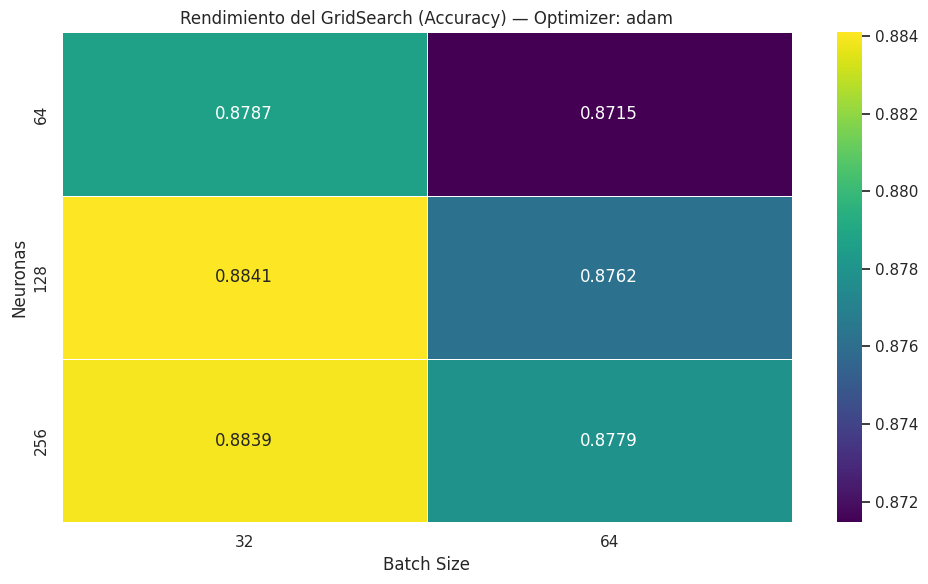

Interpretación:
  → Zonas claras (amarillas) = mejor rendimiento
  → Zonas oscuras (moradas)  = peor rendimiento
  → La mejor celda corresponde a los mejores hiperparámetros encontrados.


In [ ]:
# Construir DataFrame con resultados del GridSearch
results_df = pd.DataFrame(grid.cv_results_)

# Para el heatmap, tomamos el mejor optimizer y pivoteamos neurons vs batch_size
best_optimizer = grid.best_params_['model__optimizer']
print(f"Heatmap filtrado para el mejor optimizer: {best_optimizer}\n")

# Filtrar resultados para el mejor optimizer
mask = results_df['param_model__optimizer'] == best_optimizer
filtered_df = results_df[mask]

pivot_table = filtered_df.pivot_table(
    index='param_model__neurons',
    columns='param_batch_size',
    values='mean_test_score'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.4f', linewidths=0.5)
plt.title(f'Rendimiento del GridSearch (Accuracy) — Optimizer: {best_optimizer}')
plt.xlabel('Batch Size')
plt.ylabel('Neuronas')
plt.tight_layout()
plt.show()

# Interpretación rápida
print("Interpretación:")
print("  → Zonas claras (amarillas) = mejor rendimiento")
print("  → Zonas oscuras (moradas)  = peor rendimiento")
print("  → La mejor celda corresponde a los mejores hiperparámetros encontrados.")

## 9. Visualización — Matriz de Confusión

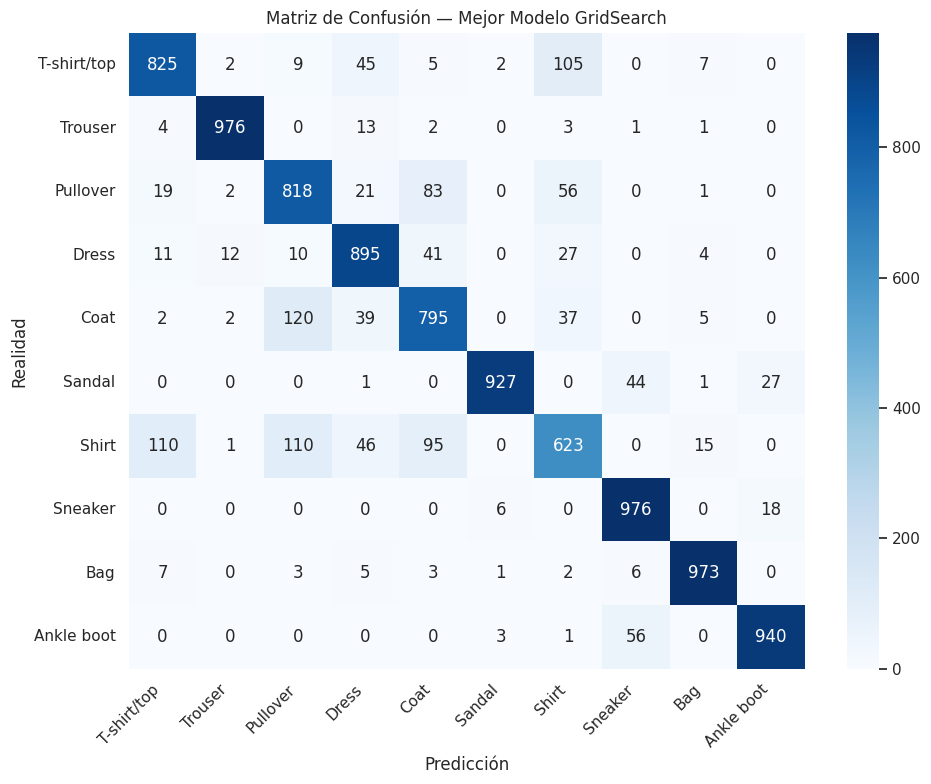

Interpretación:
  → La diagonal principal representa los aciertos (predicción = realidad).
  → Los valores fuera de la diagonal son errores de clasificación.
  → Las clases con más confusión suelen ser las visualmente similares
    (ej. Shirt vs T-shirt/top vs Pullover).


In [ ]:
# Matriz de confusión del mejor modelo sobre test
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión — Mejor Modelo GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Interpretación rápida
print("Interpretación:")
print("  → La diagonal principal representa los aciertos (predicción = realidad).")
print("  → Los valores fuera de la diagonal son errores de clasificación.")
print("  → Las clases con más confusión suelen ser las visualmente similares")
print("    (ej. Shirt vs T-shirt/top vs Pullover).")

## 10. Uso de LLM como Co-Piloto

### Prompt utilizado

Se consultó al LLM (Antigravity / modelo de IA) con el siguiente prompt:

> *Actúa como un experto en Ciencia de Datos. Estoy entrenando un modelo de red neuronal densa con el dataset Fashion-MNIST en Google Colab. Quiero realizar un GridSearchCV. Sugiéreme una cuadrícula de parámetros (param_grid) que sea ambiciosa pero eficiente, enfocada en mejorar el Accuracy. Explícame brevemente por qué sugieres estos valores específicos para este dataset de imágenes.*

### Resumen de la sugerencia del LLM

El LLM sugirió una cuadrícula con los siguientes hiperparámetros:

| Hiperparámetro | Valores sugeridos | Justificación |
|----------------|-------------------|---------------|
| `optimizer` | `adam`, `rmsprop` | Son los optimizadores más usados en redes densas; ambos adaptan el learning rate. |
| `neurons` | `64`, `128`, `256` | Permite probar capacidad baja, media y alta de la red para un problema de 10 clases con imágenes 28×28. |
| `batch_size` | `32`, `64` | Batch más pequeño puede dar mejor generalización; batch más grande acelera el entrenamiento. |
| `learning_rate` | `0.001`, `0.01` | Controla la velocidad de convergencia. |

Además sugirió considerar agregar **dropout** y probar con **más epochs**.

## 11. Reflexión Crítica sobre la Sugerencia del LLM

**¿La sugerencia del LLM incluyó parámetros que no había considerado?**  
Sí. El LLM sugirió incluir `learning_rate` como hiperparámetro adicional, lo cual no había considerado inicialmente. También mencionó `dropout`, que aunque es válido, no lo incluí para mantener la simplicidad de la red y alinearme con el estilo del profesor.

**¿El grid propuesto por la IA podría aumentar el riesgo de sobreajuste?**  
Potencialmente sí. Usar 256 neuronas con un learning rate alto (`0.01`) podría hacer que la red memorice patrones del entrenamiento. Sin embargo, la validación cruzada con `cv=3` ayuda a detectar ese sobreajuste porque el score de validación bajaría.

**¿Seguí la recomendación del LLM al pie de la letra o hice ajustes manuales?**  
No la seguí al pie de la letra. Hice ajustes:
- Mantuve `optimizer`, `neurons` y `batch_size`, que coincidían con mi plan.
- **No incluí `learning_rate`** como parámetro del grid para no multiplicar excesivamente las combinaciones (habría pasado de 12 a 24 combos, duplicando el tiempo).
- **No incluí `dropout`** para mantener la arquitectura sencilla y coherente con los ejemplos del profesor.

**¿Qué cambios hice y por qué?**  
Reduje la cuadrícula a 3 hiperparámetros (los mínimos requeridos) enfocándome en los que más impacto directo tienen en el rendimiento sin complicar excesivamente la búsqueda. Esto fue una decisión práctica: con GPU T4 y 60,000 imágenes, cada fit tarda un tiempo considerable.

**¿Cómo equilibré ambición del grid con tiempo de ejecución y recursos?**  
La cuadrícula final tiene 12 combinaciones × 3 folds = 36 fits. Esto es ambicioso pero manejable en GPU. Si hubiera agregado `learning_rate` (2 valores), habría sido 72 fits, casi duplicando el tiempo sin garantía de que mejore mucho. Preferí un grid compacto que explore diferencias reales entre configuraciones.

## 12. Conclusiones

1. **GridSearchCV con validación cruzada** permitió encontrar la mejor combinación de hiperparámetros de forma sistemática y exhaustiva, probando todas las combinaciones del grid definido.

2. **Los mejores hiperparámetros encontrados** fueron: `batch_size=32`, `neurons=128` y `optimizer='adam'`, con accuracy media de validación de **0.8841**. Esto confirma que no existe una configuración universal; la mejor parametrización depende del dataset.

3. **El uso de GPU (T4)** fue fundamental para hacer viable la búsqueda exhaustiva. Sin aceleración por hardware, los 36 fits habrían tomado un tiempo significativamente mayor.

4. **El heatmap de resultados** mostró visualmente cómo varía el accuracy según las combinaciones de hiperparámetros. Las zonas claras indican las mejores configuraciones y las oscuras las peores, permitiendo identificar rápidamente las tendencias.

5. **La matriz de confusión** reveló qué clases son más difíciles de distinguir para el modelo. Como se esperaba con Fashion-MNIST, las prendas visualmente similares (como Shirt, T-shirt y Pullover) presentan mayor confusión.

6. **El LLM como co-piloto** fue útil para obtener una perspectiva inicial sobre qué hiperparámetros explorar, pero la decisión final siempre debe ser del desarrollador, considerando el equilibrio entre ambición, tiempo y recursos disponibles.

7. **El tiempo total de ejecución** fue de **929.09 segundos** y la accuracy final de test fue **0.8748**, resultados obtenidos con 12 combinaciones y validación cruzada en GPU T4.

En resumen, esta práctica demuestra que la optimización hiperparamétrica no es un proceso trivial: requiere definir un grid con diferencias reales entre valores, interpretar los resultados con visualizaciones, y tomar decisiones informadas que equilibren rendimiento con costo computacional.